# H2 Analysis

#### 1. Imports

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
import ast
import numpy as np

#### 2. Loading the person data

In [39]:
df_persons = pd.read_csv("/Users/sophiehamann/master-thesis-code/data/output_files/09_h2_persons.csv")

print(df_persons.shape)
print(df_persons["volume"].value_counts())

(1238, 5)
volume
Vol1_late1970s     465
Vol3_late1980s     337
Vol2_early1980s    312
Vol4_early1990s    124
Name: count, dtype: int64


#### 3. Assigning the volume groups

In [40]:
def get_issue_number(filepath):
    match = re.search(r"heresies_(\d+)_combined", filepath)
    return int(match.group(1)) if match else None

def get_volume(issue_nr):
    if issue_nr <= 4:
        return "Vol1_late1970s"
    elif issue_nr <= 8:
        return "Vol2_early1980s"
    elif issue_nr <= 12:
        return "Vol3_late1980s"
    elif issue_nr <= 16:
        return "Vol4_early1990s"
    elif issue_nr <= 20:
        return "Vol5"
    elif issue_nr <= 24:
        return "Vol6"
    else:
        return "Vol7"

df_persons["issue"]  = df_persons["source_file"].apply(get_issue_number)
df_persons["volume"] = df_persons["issue"].apply(get_volume)
df_persons = df_persons[df_persons["issue"] <= 14]

print(df_persons["volume"].value_counts())

volume
Vol1_late1970s     465
Vol3_late1980s     337
Vol2_early1980s    312
Vol4_early1990s    124
Name: count, dtype: int64


#### 4. Person Frequency per volume

In [41]:
# count how often each person is mentioned per volume
freq = df_persons.groupby(["volume", "person"]).size().reset_index(name="count")
print(freq.head(20))

            volume                       person  count
0   Vol1_late1970s  ALICE DICK b. NEW BRUNSWICK      1
1   Vol1_late1970s         Abbe Jacques Boileau      1
2   Vol1_late1970s                Adele Raiffen      1
3   Vol1_late1970s          Adrian A. Gerbrands      1
4   Vol1_late1970s                Adrienne Rich      2
5   Vol1_late1970s             Albert C. Barnes      1
6   Vol1_late1970s               Albert Gleizes      2
7   Vol1_late1970s                Albert Museum      1
8   Vol1_late1970s                 Alice Aycock      1
9   Vol1_late1970s                  Alma Mahler      1
10  Vol1_late1970s                Alma Routsong      1
11  Vol1_late1970s                   Amy Goldin      1
12  Vol1_late1970s                  Amy Sillman      2
13  Vol1_late1970s               Andra Samelson      1
14  Vol1_late1970s                Andre Malraux      1
15  Vol1_late1970s                André Malraux      2
16  Vol1_late1970s          Angelica Balabanoff      1
17  Vol1_l

#### 5. Top theorists per volume

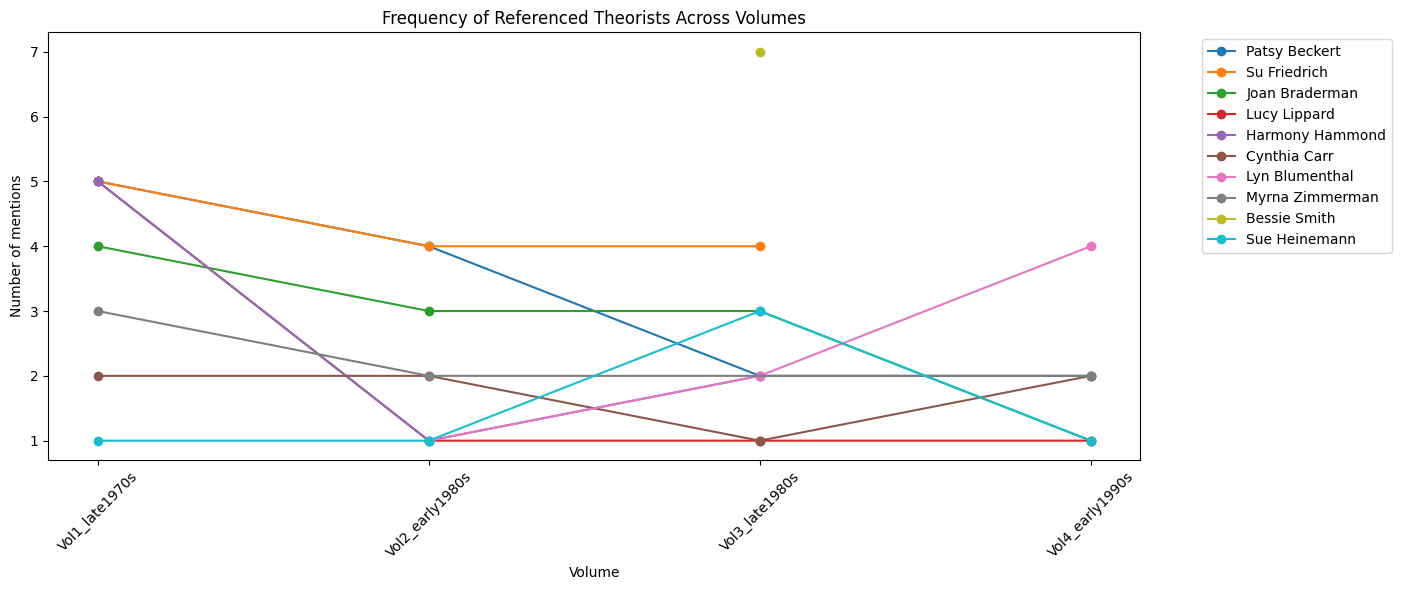

In [42]:
# get top 10 most mentioned people overall
top_persons = df_persons["person"].value_counts().head(10).index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))

for person in top_persons:
    person_data = freq[freq["person"] == person]
    ax.plot(person_data["volume"], person_data["count"], marker="o", label=person)

ax.set_xlabel("Volume")
ax.set_ylabel("Number of mentions")
ax.set_title("Frequency of Referenced Theorists Across Volumes")
ax.legend(bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h2_theorist_frequency.png")
plt.show()

#### 6. Load lemmatized text for co-occurrence

In [43]:
df_text = pd.read_csv("/Users/sophiehamann/master-thesis-code/data/output_files/11_h2_lemmatized.csv")
df_text["tokens"] = df_text["tokens"].apply(ast.literal_eval)
df_text["issue"]  = df_text["source_file"].apply(get_issue_number)
df_text["volume"] = df_text["issue"].apply(get_volume)
df_text = df_text[df_text["issue"] <= 14]
print(df_text.shape)

(12620, 7)


#### 7. Co-occurrence: Theorists near concepts

# how are these concepts DEFINED?????? --> DAS IST WICHTIG!!!!

In [44]:
concepts = ["body", "experience", "nature", "difference", 
            "sexuality", "identity", "construction", "discourse", "power"]

window  = 10
results = []

all_theorists = df_persons["person"].unique().tolist()

for _, row in df_text.iterrows():
    text   = " ".join(row["tokens"])
    volume = row["volume"]
    
    for theorist in all_theorists:
        # match full name in text
        name_lower = theorist.lower()
        
        if name_lower in text:
            # find position and check window
            tokens = row["tokens"]
            for i, token in enumerate(tokens):
                if token == name_lower.split()[0]:
                    start         = max(0, i - window)
                    end           = min(len(tokens), i + window)
                    window_tokens = tokens[start:end]
                    
                    for concept in concepts:
                        if concept in window_tokens:
                            results.append({
                                "theorist": theorist,
                                "concept":  concept,
                                "volume":   volume
                            })

df_cooc = pd.DataFrame(results)
print(f"Total co-occurrences found: {len(df_cooc)}")
print(df_cooc.head(20))

Total co-occurrences found: 7
           theorist     concept           volume
0      Anna Halprin        body   Vol1_late1970s
1   Hannah Alderfer   sexuality   Vol3_late1980s
2   Sandra De Sando   sexuality   Vol3_late1980s
3        Beth Jaker   sexuality   Vol3_late1980s
4         Kay Kenny   sexuality   Vol3_late1980s
5  Janet Culbertson      nature  Vol4_early1990s
6       R. D. Laing  experience  Vol2_early1980s


#### 9. Saving results

In [46]:
freq.to_csv("/Users/sophiehamann/master-thesis-code/data/output_files/13_h2_person_frequency.csv", index=False)
df_cooc.to_csv("/Users/sophiehamann/master-thesis-code/data/output_files/13_h2_cooccurrence.csv", index=False)